In [ ]:
# Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import io
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas


In [2]:

# function to load datasets based on condition's file path
def load_dataset(file_path):
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        print(f"File not found: {file_path}")
        return None
    
# Example usage
all_data = load_dataset('c:/Users/fkamdar/Desktop/emotionalRBDandPD/Data/MergedData/megadata.csv')
controls = load_dataset('c:/Users/fkamdar/Desktop/emotionalRBDandPD/Data/MergedData/megadata_controls.csv')
pd_patients_off = load_dataset('c:/Users/fkamdar/Desktop/emotionalRBDandPD/Data/MergedData/megadata_pd_patients_off.csv')
pd_patients_on = load_dataset('c:/Users/fkamdar/Desktop/emotionalRBDandPD/Data/MergedData/megadata_pd_patients_on.csv')
rbd_patients = load_dataset('c:/Users/fkamdar/Desktop/emotionalRBDandPD/Data/MergedData/megadata_rbd_patients.csv')    

# all_data.columns.tolist()

In [3]:

control_subjects = controls['SubjectID'].unique()
control_subjects = np.sort(control_subjects)

pd_patients_off_subjects = pd_patients_off['SubjectID'].unique()
pd_patients_off_subjects = np.sort(pd_patients_off_subjects)

pd_patients_on_subjects = pd_patients_on['SubjectID'].unique()
pd_patients_on_subjects = np.sort(pd_patients_on_subjects)

rbd_patients_subjects = rbd_patients['SubjectID'].unique()
rbd_patients_subjects = np.sort(rbd_patients_subjects)

# print(f"Control Ids: {control_subjects} count: {len(control_subjects)}")
# print(f"PD Patients Off Medication Ids: {pd_patients_off_subjects} count: {len(pd_patients_off_subjects)}")
# print(f"PD Patients On Medication Ids: {pd_patients_on_subjects} count: {len(pd_patients_on_subjects)}")
# print(f"RBD Patients Ids: {rbd_patients_subjects} count: {len(rbd_patients_subjects)}")



Control Ids: [   2    6    7   10   13   16   17   18   19   20   21   30   33   34
   37   38   39   40   41   42   46   51   52   57   60   64   72   76
   80   91   99 4868] count: 32
PD Patients Off Medication Ids: [   2    4    5    6   13   15   22   28   29   30   31   32   33   34
   35   36   37   38   40   41   42   44 3237 4868] count: 24
PD Patients On Medication Ids: [   2    4    5    6   13   15   22   28   29   30   31   32   33   34
   35   36   37   38   40   41   42   44 3237 4868] count: 24
RBD Patients Ids: [ 3  4  5 11 14 22 23 25 26 28 31 32 36 38 44 47 55 56 63 67 71 83 85 88
 97] count: 25


In [4]:
# Plotting function for valence vs normative valence
def plot_valence_vs_normative(data, output_dir, condition):
    subj = data['SubjectID'].values[0]
    normative_valence_ratings = data['normative_valence'].values
    valence_ratings = data['valence_rating'].values

    # Mask: keep only rows where both ratings are not NaN
    mask = ~np.isnan(normative_valence_ratings) & ~np.isnan(valence_ratings)
    num_valence_nans = np.isnan(valence_ratings).sum()
    norm_vals_clean = normative_valence_ratings[mask]
    valence_clean = valence_ratings[mask]

    plt.figure(figsize=(8, 5))
    plt.scatter(norm_vals_clean, valence_clean, alpha=0.7)

    # Fit a linear regression (1st degree polynomial)
    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)

    # Plot the fitted line and y=x line
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
    plt.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    plt.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
    plt.xlabel('Normative Ratings')
    plt.ylabel('Valence Ratings')
    plt.title(f'{condition} {subj} Valence Ratings')
    plt.xticks(np.arange(1, 10, 1))
    plt.yticks(np.arange(1, 10, 1))
    plt.xlim(1, 9)
    plt.ylim(0, 10)
    plt.figtext(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red')
    plt.grid(True)
    plt.tight_layout()

    # Save figure
    # plt.savefig(os.path.join(output_dir, f"subject_{subj}_valence_ratings_fit.png"))
    # plt.close()


# plotting function for arousal vs normative arousal
def plot_arousal_vs_normative(data, output_dir, condition):
    subj = data['SubjectID'].values[0]
    normative_arousal_ratings = data['normative_arousal'].values
    arousal_ratings = data['arousal_rating'].values
    # Mask: keep only rows where both ratings are not NaN
    mask = ~np.isnan(normative_arousal_ratings) & ~np.isnan(arousal_ratings)
    num_arousal_nans = np.isnan(arousal_ratings).sum()
    norm_arousal_clean = normative_arousal_ratings[mask]
    arousal_clean = arousal_ratings[mask]
    plt.figure(figsize=(8, 5))
    plt.scatter(norm_arousal_clean, arousal_clean, alpha=0.7)
    # Fit a linear regression (1st degree polynomial)
    coeffs = np.polyfit(norm_arousal_clean, arousal_clean, 1)
    fit_fn = np.poly1d(coeffs)
    # Plot the fitted line and y=x line
    x_fit = np.linspace(norm_arousal_clean.min(), norm_arousal_clean.max(), 100)
    plt.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    plt.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
    plt.xlabel('Normative Ratings')
    plt.ylabel('Arousal Ratings')
    plt.title(f'{condition} {subj} Arousal Ratings')
    plt.xticks(np.arange(1, 10, 1))
    plt.yticks(np.arange(1, 10, 1))
    plt.xlim(1, 9)
    plt.ylim(0, 10)
    plt.figtext(0.75, 0.15, f'Number of NaNs: {num_arousal_nans}', fontsize=10, color='red')
    plt.grid(True)
    plt.tight_layout()
    # Save figure
    # plt.savefig(os.path.join(output_dir, f"subject_{subj}_arousal_ratings_fit.png"))
    # plt.close()
    

In [ ]:
# CALLING THE FUNCTIONS FOR EACH GROUP

# CONTROLS
output_dir = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence vs norrmative\control"
os.makedirs(output_dir, exist_ok=True)
output_dir2 = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\arousal vs norrmative\control"
os.makedirs(output_dir2, exist_ok=True)

for subj in control_subjects:
    subj_data = controls[controls['SubjectID'] == subj]
    plot_valence_vs_normative(data=subj_data, output_dir=output_dir, condition='Control Subject')
    plot_arousal_vs_normative(data=subj_data, output_dir=output_dir2, condition='Control Subject')

# PD Patients Off Medication
output_dir = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence vs norrmative\pd_patients_off"
os.makedirs(output_dir, exist_ok=True)
output_dir2 = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\arousal vs norrmative\pd_patients_off"
os.makedirs(output_dir2, exist_ok=True)
for subj in pd_patients_off_subjects:
    subj_data = pd_patients_off[pd_patients_off['SubjectID'] == subj]
    plot_valence_vs_normative(data=subj_data, output_dir=output_dir, condition='PD OFF Med Subject')
    plot_arousal_vs_normative(data=subj_data, output_dir=output_dir2, condition='PD OFF Med Subject')

# PD Patients On Medication
output_dir = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence vs norrmative\pd_patients_on"
os.makedirs(output_dir, exist_ok=True)
output_dir2 = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\arousal vs norrmative\pd_patients_on"
os.makedirs(output_dir2, exist_ok=True)
for subj in pd_patients_on_subjects:
    subj_data = pd_patients_on[pd_patients_on['SubjectID'] == subj]
    plot_valence_vs_normative(data=subj_data, output_dir=output_dir, condition='PD ON Med Subject')
    plot_arousal_vs_normative(data=subj_data, output_dir=output_dir2, condition='PD ON Med Subject')

# RBD Patients
output_dir = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence vs norrmative\rbd_patients"
os.makedirs(output_dir, exist_ok=True)
output_dir2 = r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\arousal vs norrmative\rbd_patients"
os.makedirs(output_dir2, exist_ok=True)
for subj in rbd_patients_subjects:
    subj_data = rbd_patients[rbd_patients['SubjectID'] == subj]
    plot_valence_vs_normative(data=subj_data, output_dir=output_dir, condition='RBD Subject')
    plot_arousal_vs_normative(data=subj_data, output_dir=output_dir2, condition='RBD Subject')




In [5]:


def _fig_to_array_and_close():
    fig = plt.gcf()
    canvas = FigureCanvas(fig)
    canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.asarray(canvas.buffer_rgba())
    img = buf[:, :, :3]  # drop alpha channel
    plt.close(fig)
    return img

def show_valence_arousal_side_by_side(subj_data, condition):
    subj = subj_data['SubjectID'].values[0]

    # make valence fig via your existing function
    plot_valence_vs_normative(subj_data, ".", condition)
    img_val = _fig_to_array_and_close()

    # make arousal fig
    plot_arousal_vs_normative(subj_data, ".", condition)
    img_aro = _fig_to_array_and_close()

    # side by side in one figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(img_val)
    axes[0].axis("off")
    axes[1].imshow(img_aro)
    axes[1].axis("off")
    plt.show()



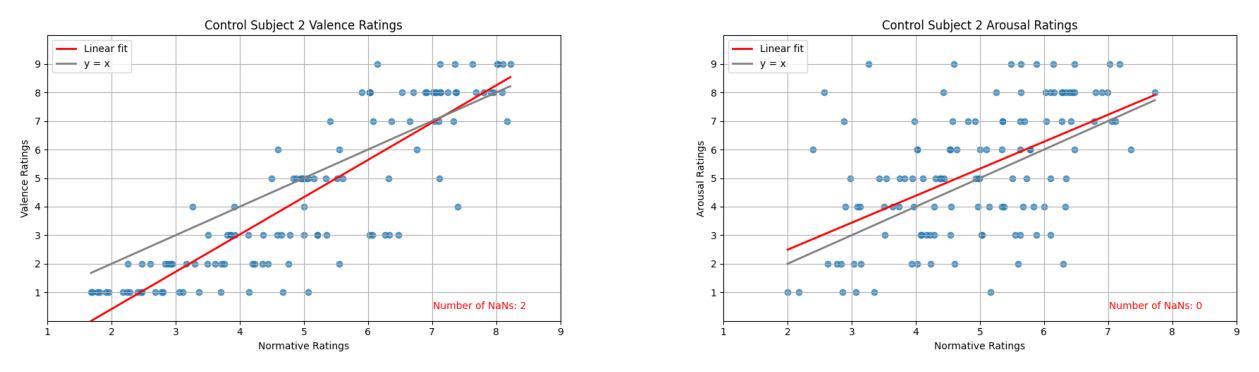

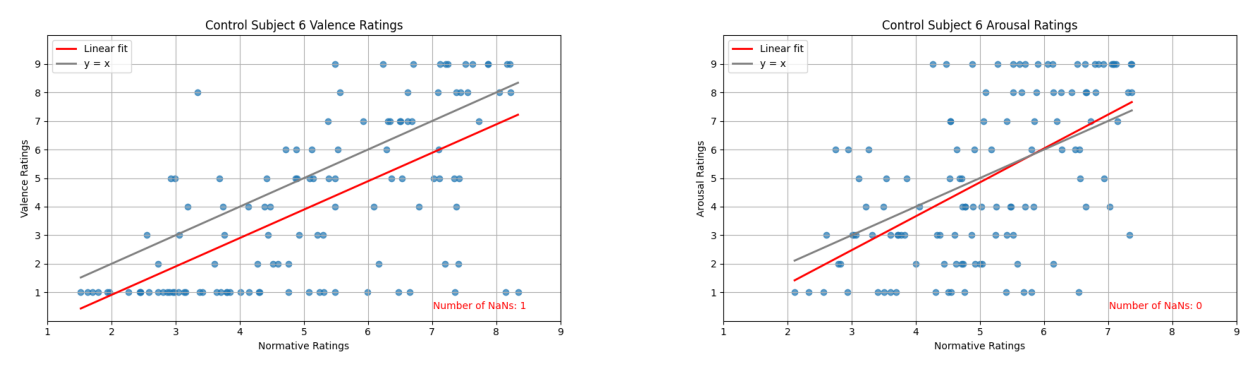

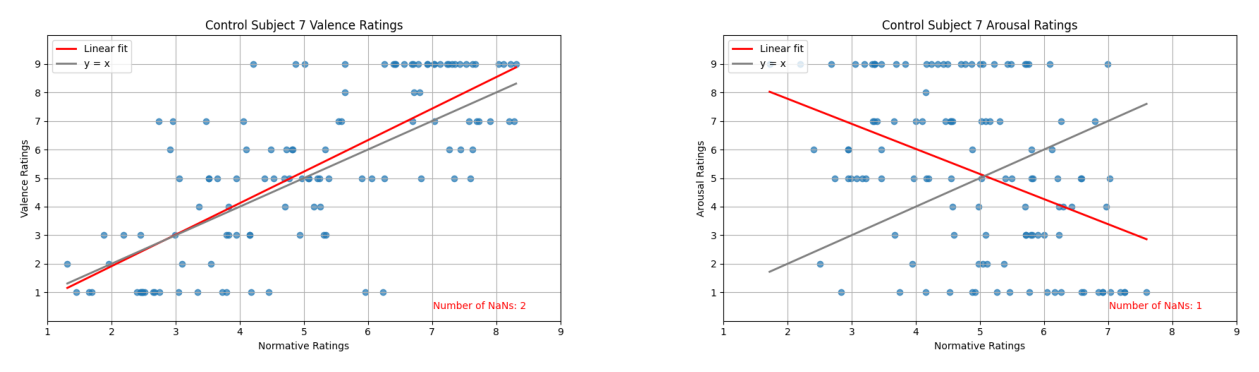

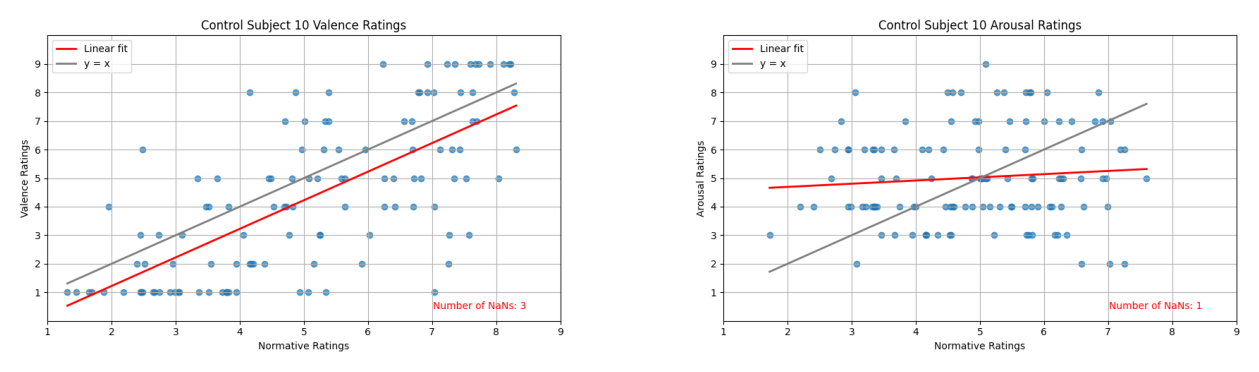

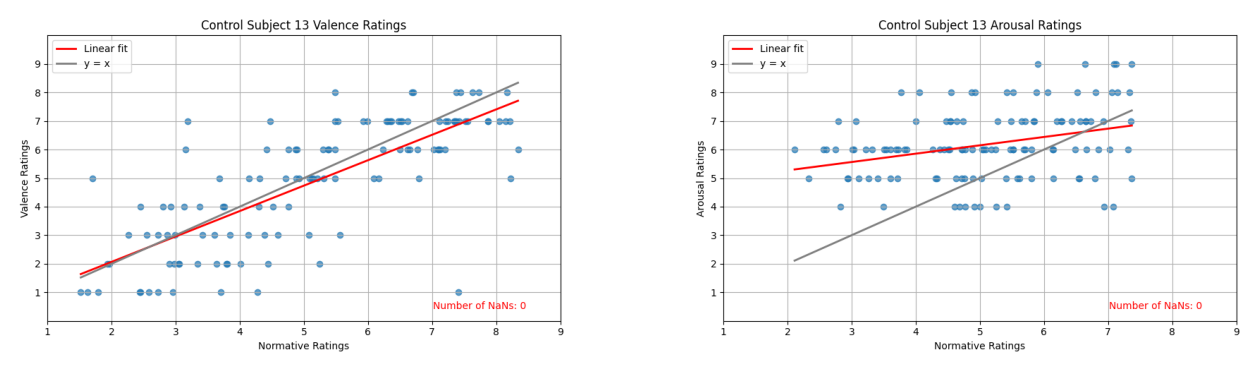

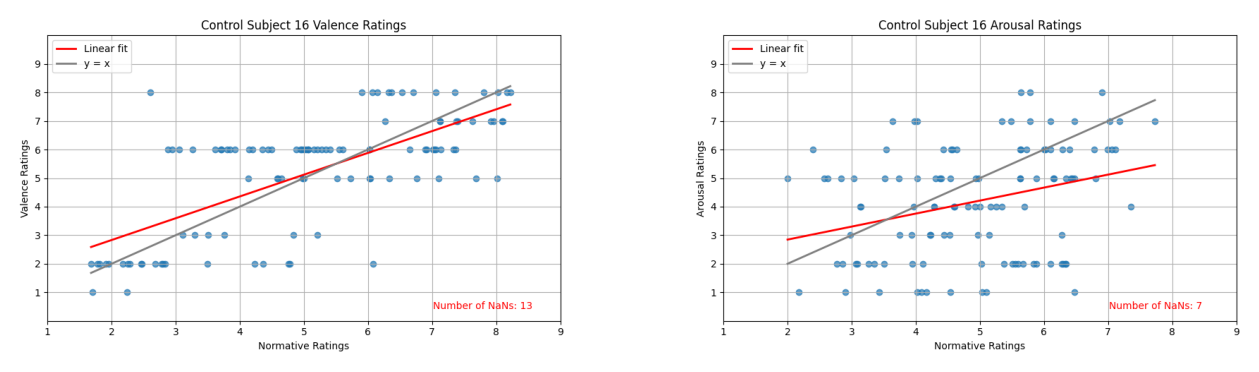

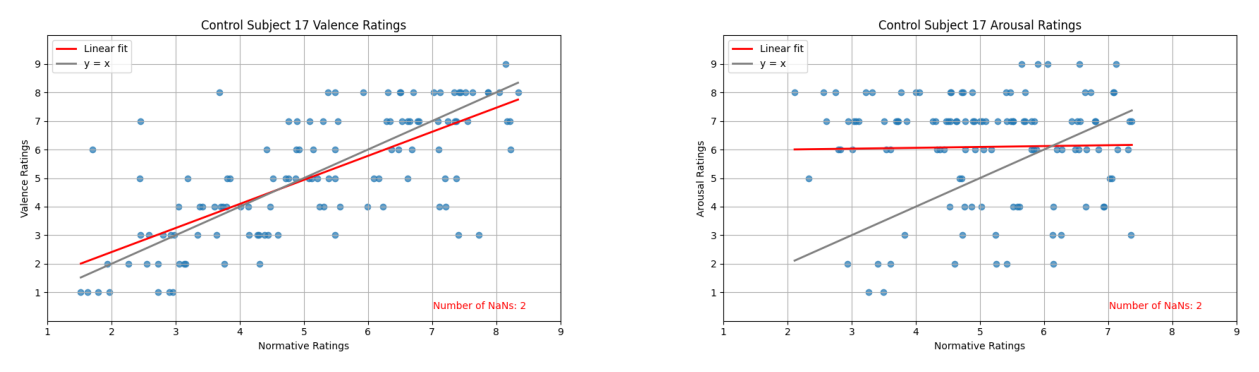

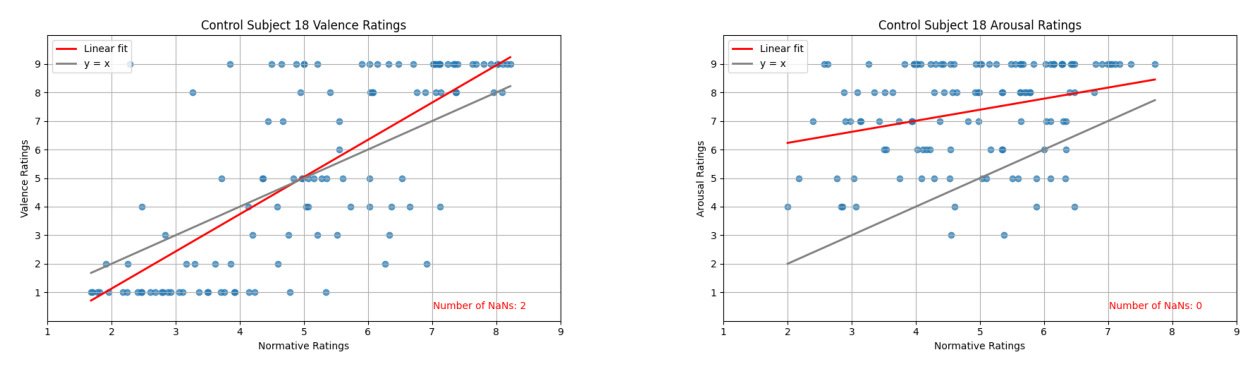

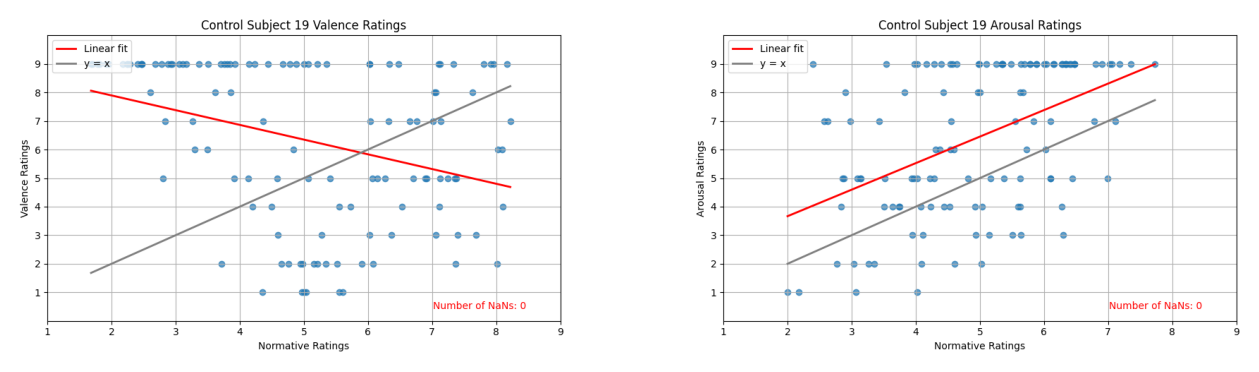

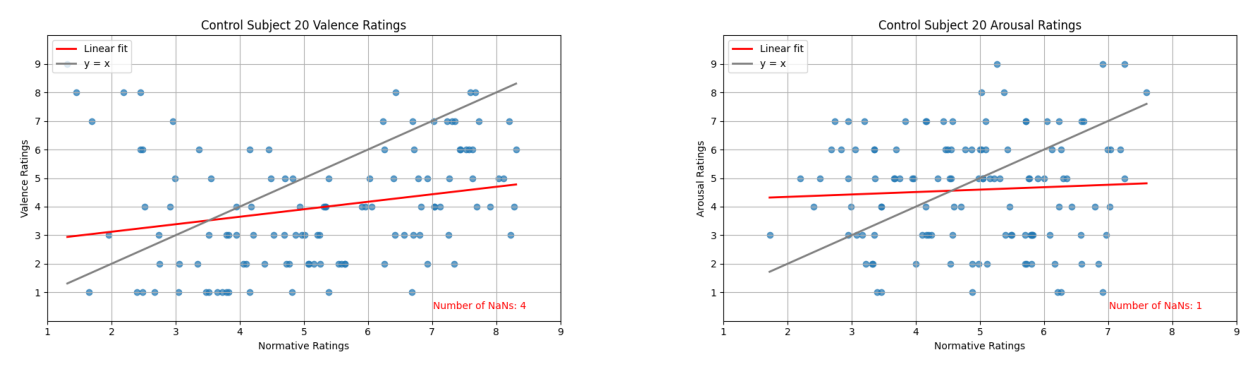

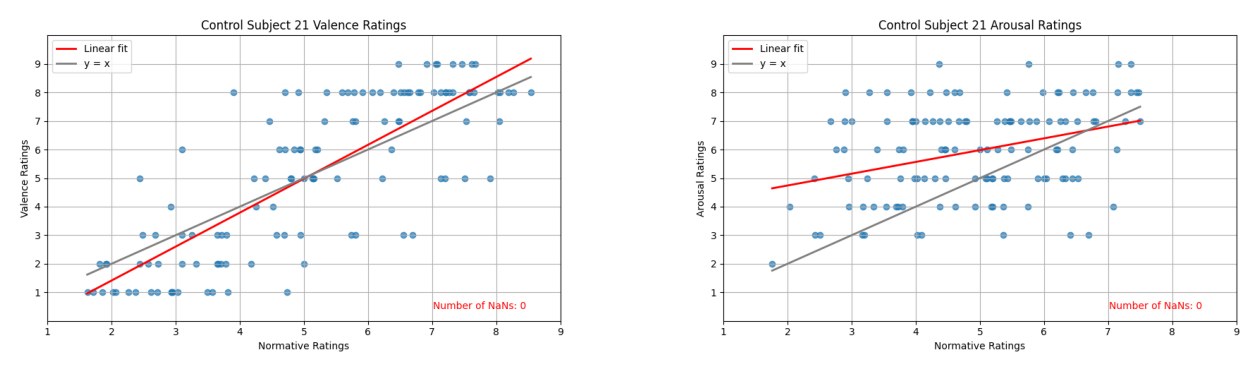

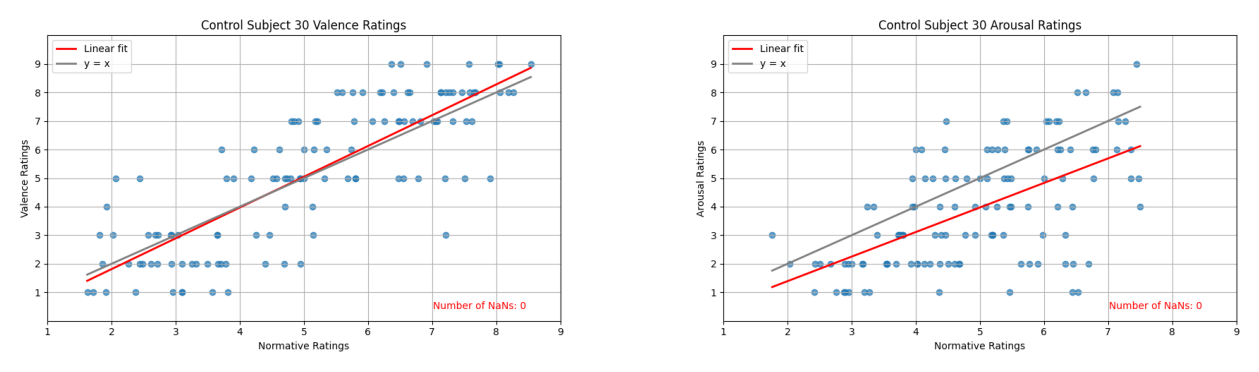

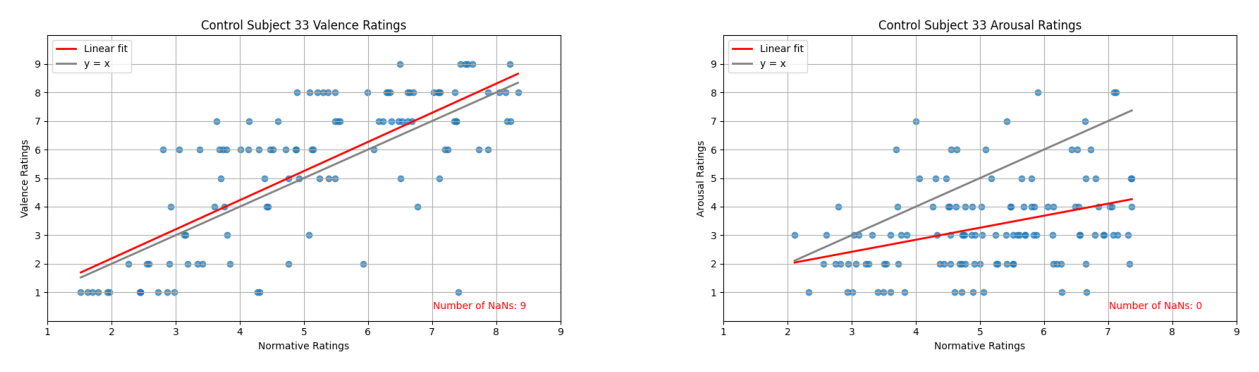

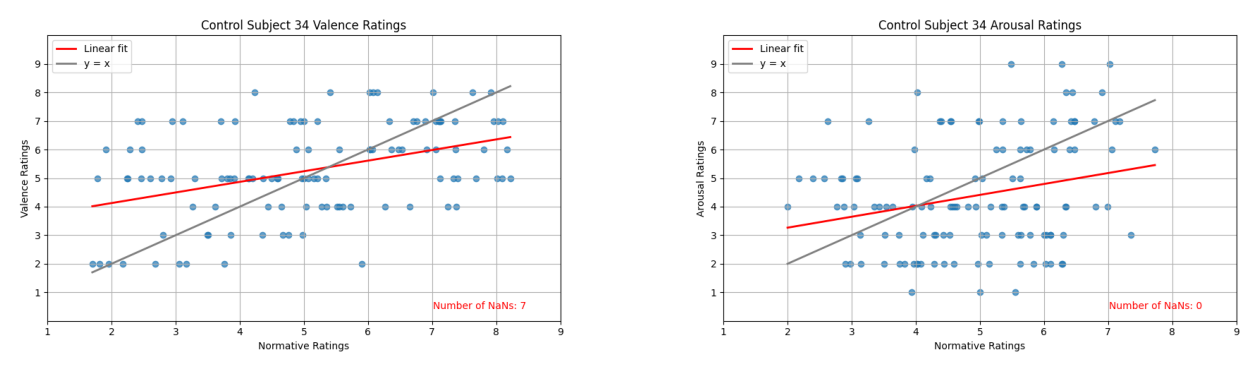

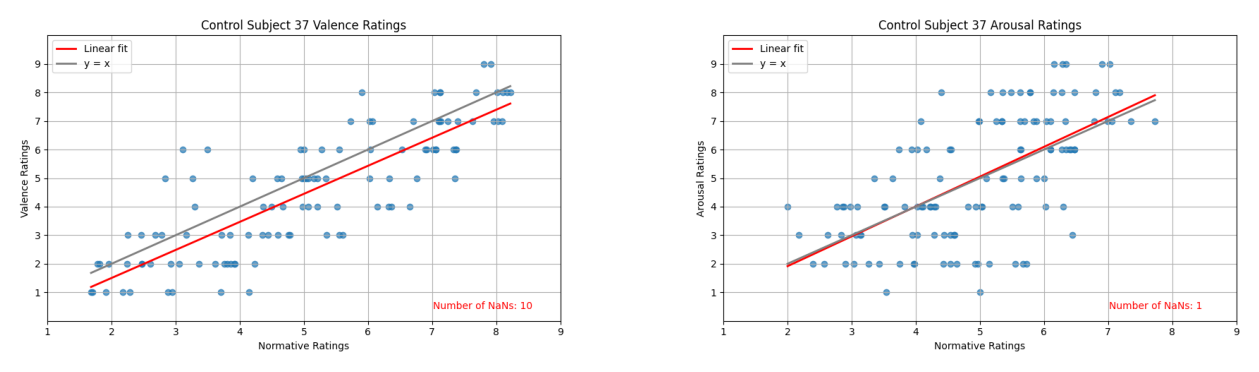

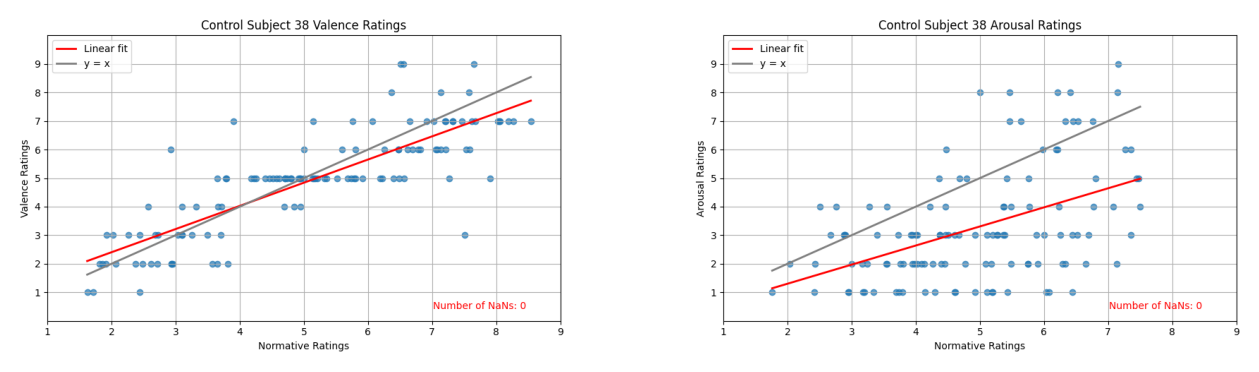

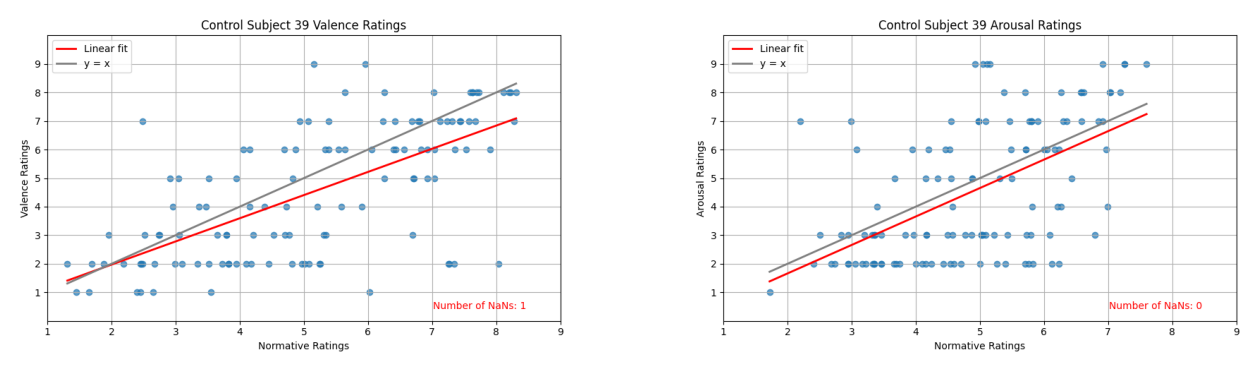

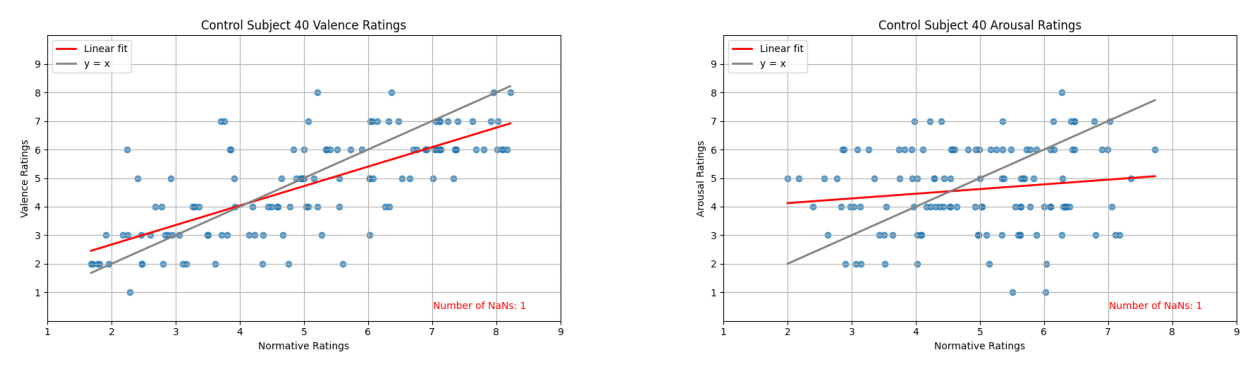

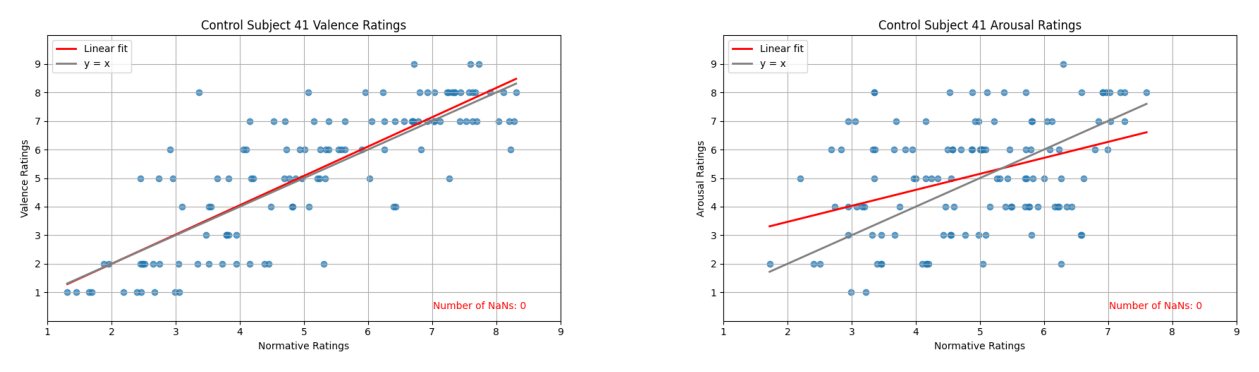

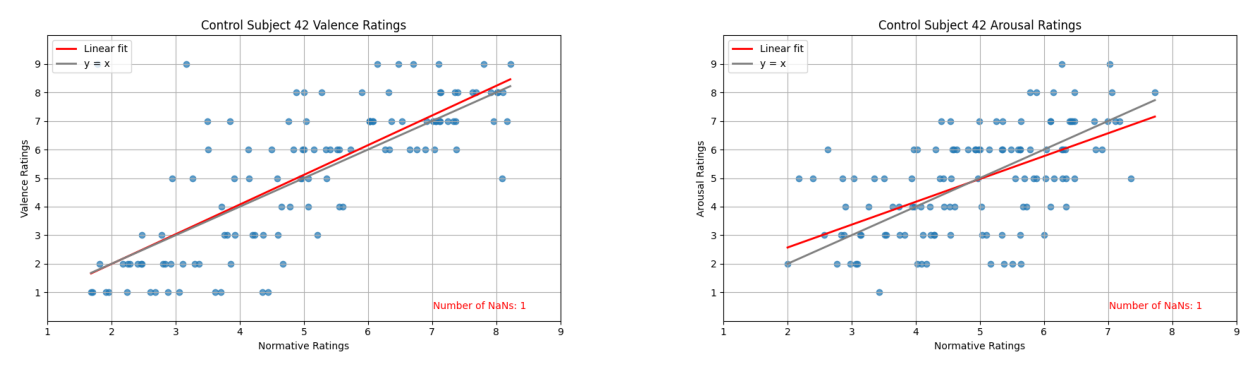

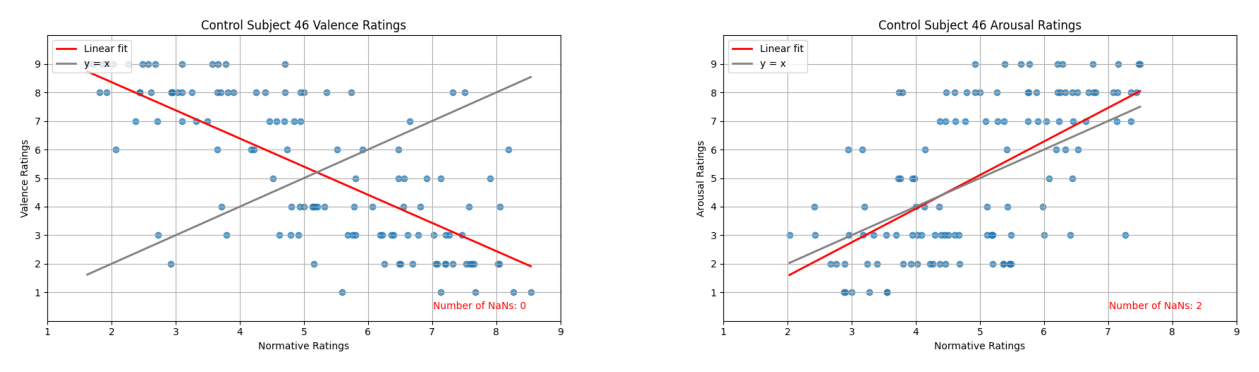

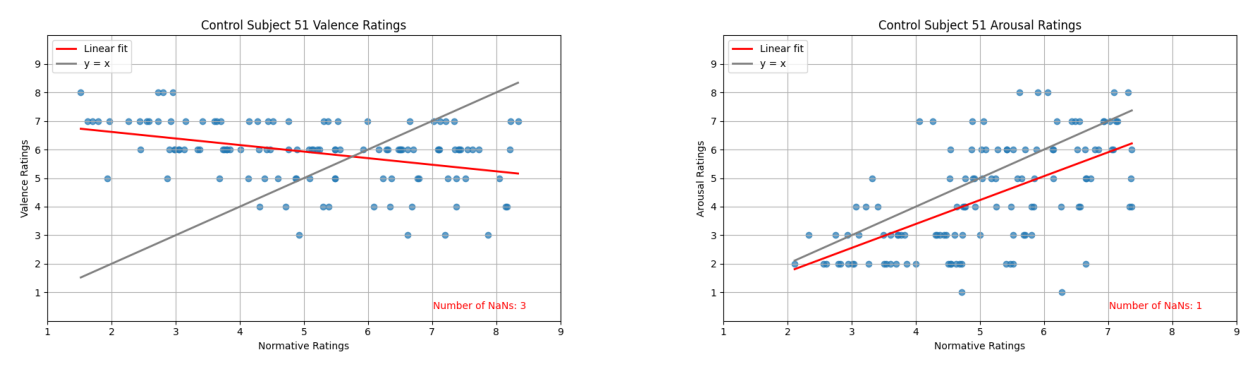

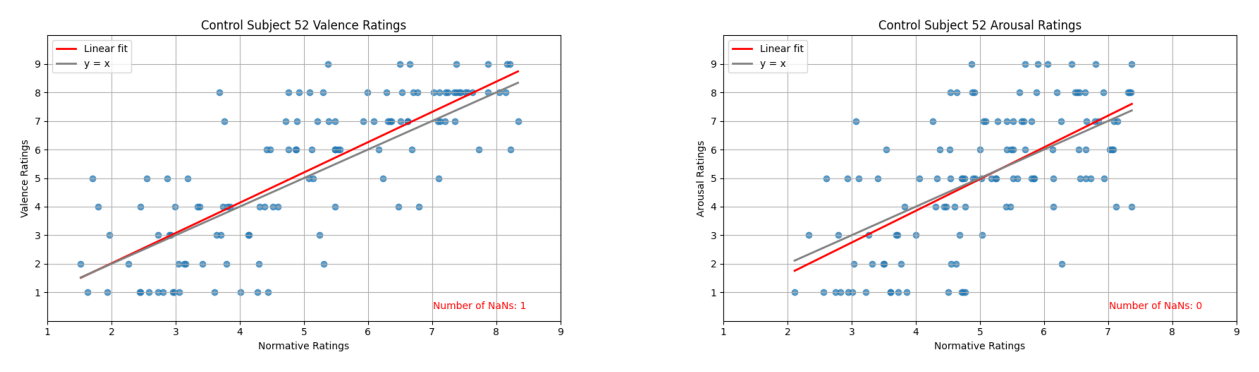

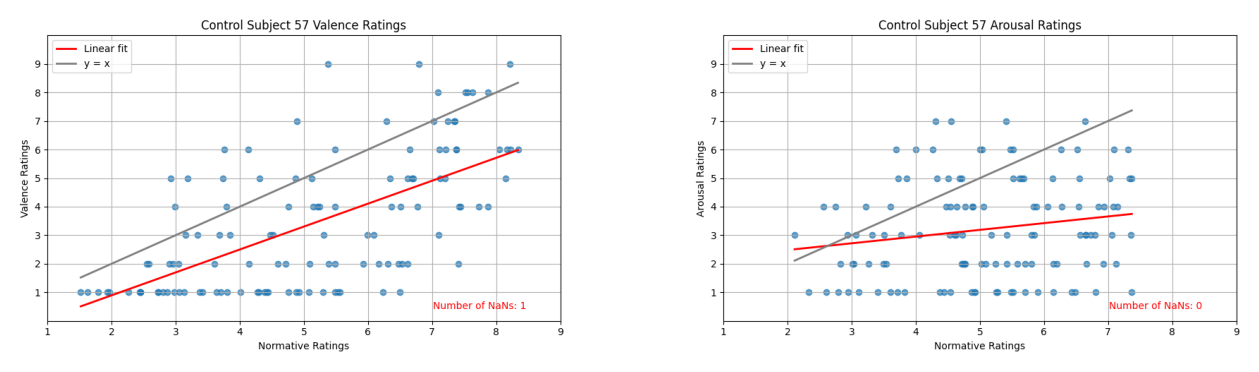

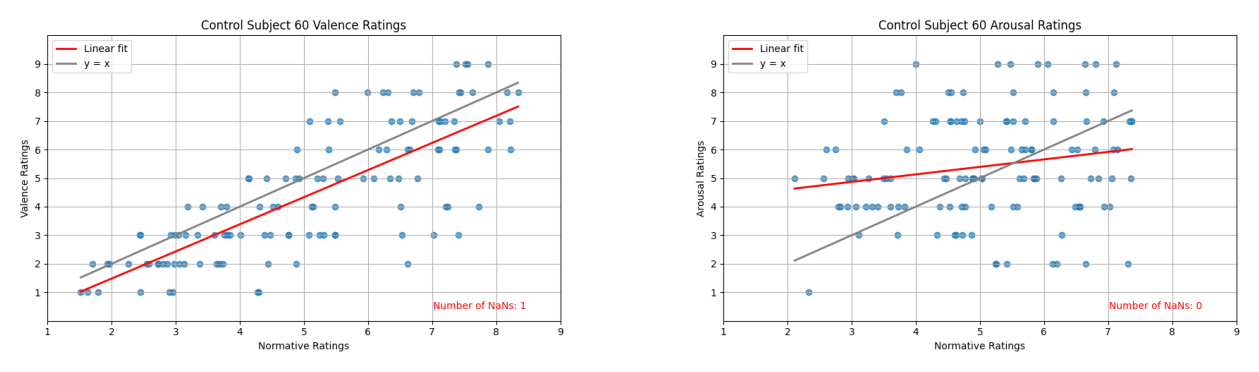

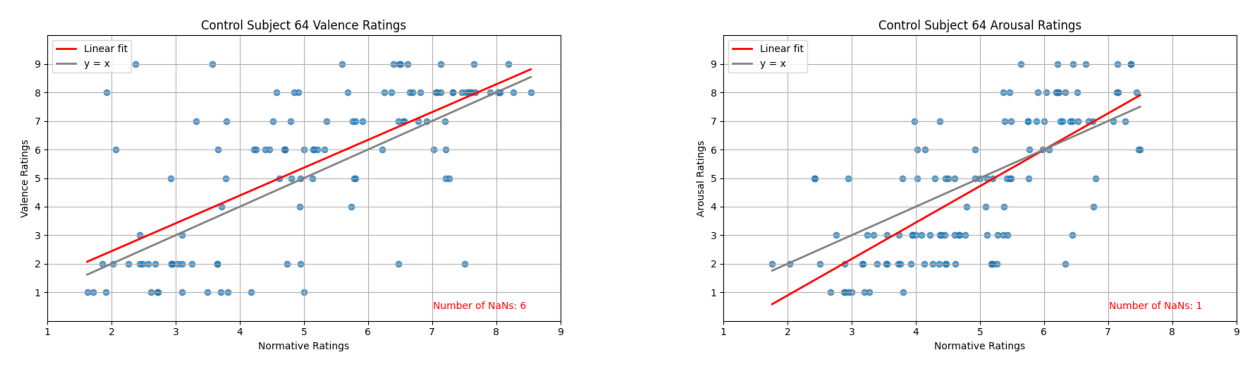

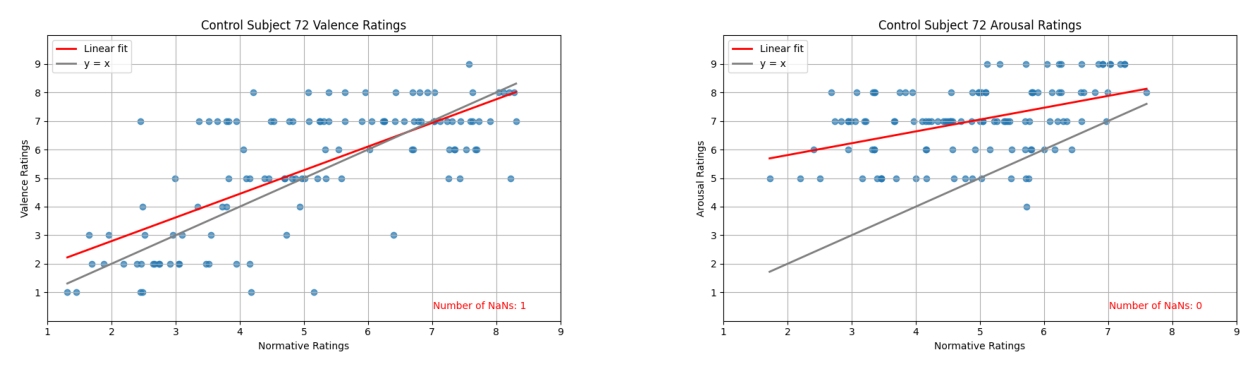

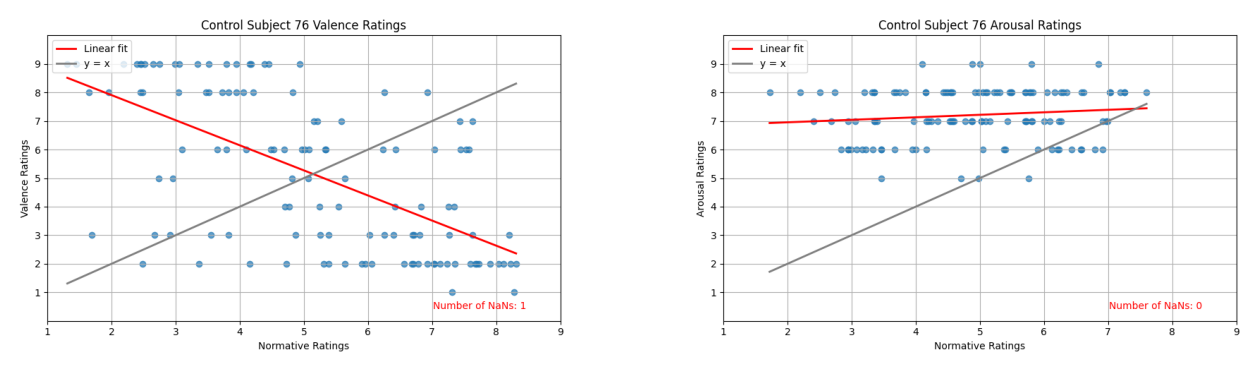

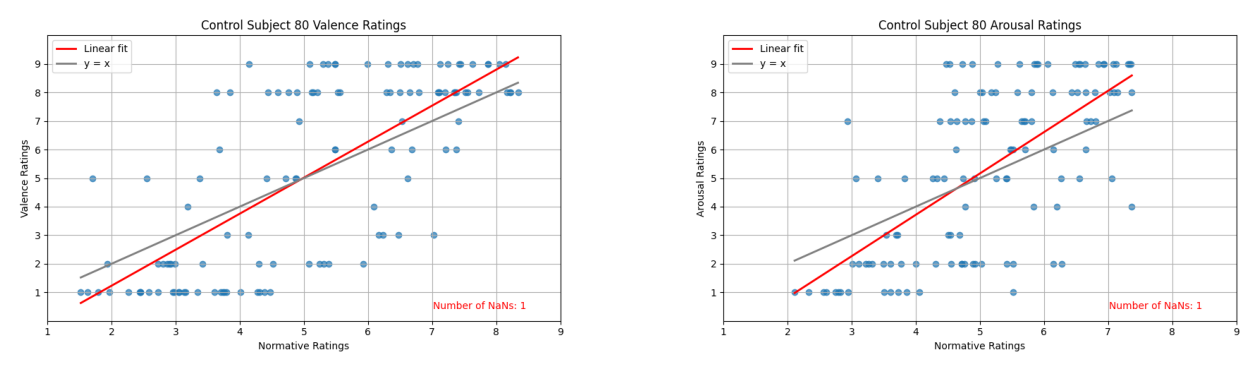

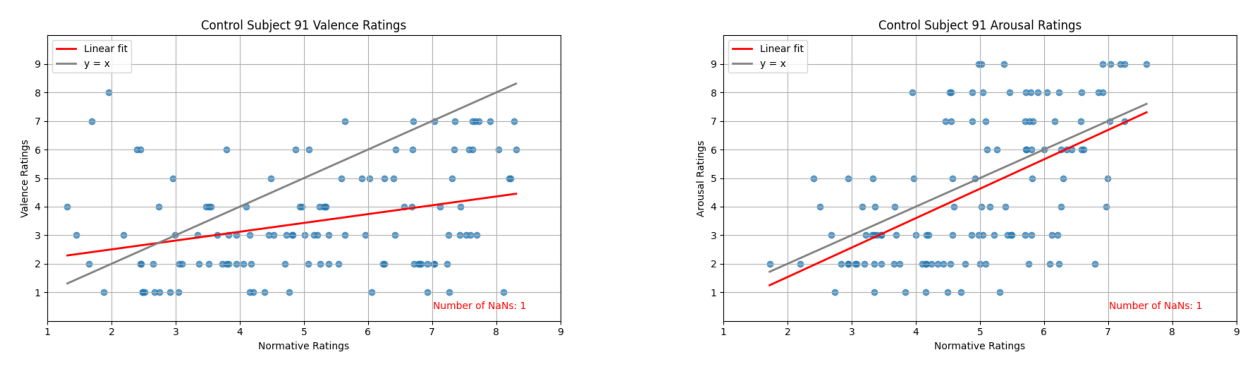

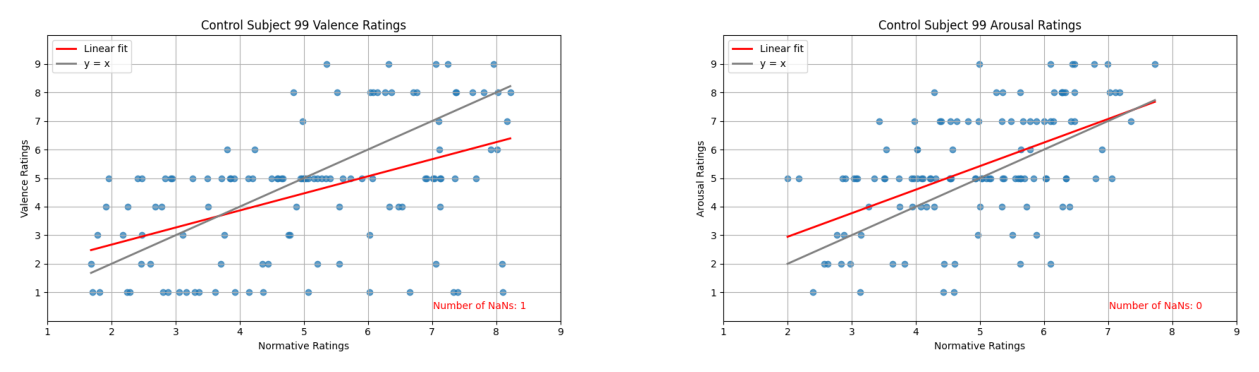

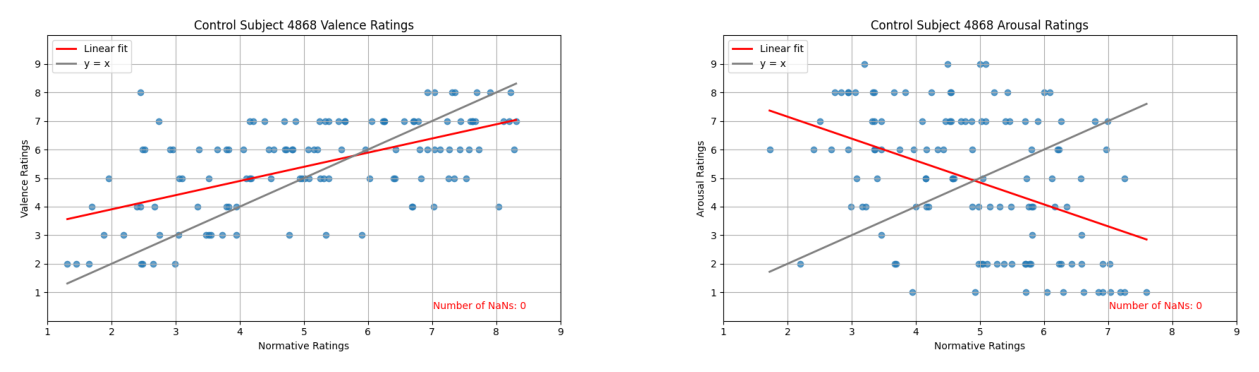

In [6]:
# Loop through all control subjects and display side-by-side plots
for subj in control_subjects:
    subj_data = controls[controls['SubjectID'] == subj]
    show_valence_arousal_side_by_side(subj_data, "Control Subject")



In [10]:
import io
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from pptx import Presentation
from pptx.util import Inches, Pt

# --- capture CURRENT Matplotlib figure to PNG bytes, then close it ---
def _fig_to_png_bytes_and_close(dpi=200):
    fig = plt.gcf()
    FigureCanvas(fig).draw()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return buf

# --- add one slide for a subject: runs your funcs and places images side-by-side ---
def _add_subject_slide(prs, subj_data, condition, group_label=None):
    subj = subj_data['SubjectID'].values[0]

    # run your existing plotters (no changes)
    plot_valence_vs_normative(subj_data, ".", condition)
    val_png = _fig_to_png_bytes_and_close(dpi=200)

    plot_arousal_vs_normative(subj_data, ".", condition)
    aro_png = _fig_to_png_bytes_and_close(dpi=200)

    # blank slide
    slide = prs.slides.add_slide(prs.slide_layouts[6])  # 6 = Blank

    # title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(12.3), Inches(0.8))
    tf = title_box.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    prefix = f"{group_label} – " if group_label else ""
    p.text = f"{prefix}{condition} {subj}: Valence & Arousal vs Normative"
    p.font.size = Pt(24)

    # layout math (16:9 deck: 13.333 in x 7.5 in)
    slide_w_in = 13.333
    left_margin, right_margin, top_in, gap_in = 0.5, 0.5, 1.1, 0.3
    available_w = slide_w_in - left_margin - right_margin - gap_in
    panel_w = available_w / 2.0

    # place images
    slide.shapes.add_picture(val_png, Inches(left_margin), Inches(top_in), width=Inches(panel_w))
    slide.shapes.add_picture(aro_png, Inches(left_margin + panel_w + gap_in), Inches(top_in), width=Inches(panel_w))

# --- add a group's title slide + all its subject slides ---
def _add_group(prs, group_title, df, subject_ids, condition):
    # group title slide
    slide = prs.slides.add_slide(prs.slide_layouts[0])  # Title slide
    slide.shapes.title.text = group_title
    try:
        slide.placeholders[1].text = "One subject per slide (side-by-side panels)"
    except Exception:
        pass

    # subject slides
    for subj in subject_ids:
        subj_data = df[df['SubjectID'] == subj]
        if len(subj_data) == 0:
            continue
        _add_subject_slide(prs, subj_data, condition, group_label=group_title)

# --- main: build a single deck with all four groups ---
def make_all_groups_deck(
    controls_df, control_subjects,
    pd_off_df, pd_off_subjects,
    pd_on_df, pd_on_subjects,
    rbd_df, rbd_subjects,
    output_path=r"C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence_arousal_ALL_groups.pptx"
):
    prs = Presentation()
    # set 16:9 explicitly
    prs.slide_width = Inches(13.333)
    prs.slide_height = Inches(7.5)

    # cover slide
    cover = prs.slides.add_slide(prs.slide_layouts[0])
    cover.shapes.title.text = "Valence & Arousal vs Normative — All Groups"
    try:
        cover.placeholders[1].text = "Controls • PD OFF • PD ON • RBD"
    except Exception:
        pass

    # add each group section
    _add_group(prs, "Controls", controls_df, control_subjects, condition="Control Subject")
    _add_group(prs, "PD OFF Medication", pd_off_df, pd_off_subjects, condition="PD OFF Med Subject")
    _add_group(prs, "PD ON Medication", pd_on_df, pd_on_subjects, condition="PD ON Med Subject")
    _add_group(prs, "RBD Patients", rbd_df, rbd_subjects, condition="RBD Subject")

    prs.save(output_path)
    print(f"✅ PPT saved to: {output_path}")


In [11]:
make_all_groups_deck(
    controls_df=controls, control_subjects=control_subjects,
    pd_off_df=pd_patients_off, pd_off_subjects=pd_patients_off_subjects,
    pd_on_df=pd_patients_on, pd_on_subjects=pd_patients_on_subjects,
    rbd_df=rbd_patients, rbd_subjects=rbd_patients_subjects
)


✅ PPT saved to: C:\Users\fkamdar\Desktop\emotionalRBDandPD\plots\valence_arousal_ALL_groups.pptx
